In [54]:
import math
import torch
from torch import nn
from torch import Tensor
from torch.nn  import functional as F
import gpytorch
from matplotlib import pyplot as plt
from torch.distributions.multivariate_normal import MultivariateNormal
import matplotlib.cm as cm
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D 
import sys
from decimal import Decimal
from IPython.display import clear_output
sys.path.append("..")
from utils import ObjFun, get_vertices, stopping_criteria
from scipy import stats
import numpy as np
import scipy.io
import seaborn as sns
import scipy
import os
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
sns.set_style('white') # darkgrid, white grid, dark, white and ticks
plt.rc('axes', titlesize=40)     # fontsize of the axes title
plt.rc('axes', labelsize=32)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=32)    # fontsize of the tick labels
plt.rc('ytick', labelsize=32)    # fontsize of the tick labels
plt.rc('legend', fontsize=32)    # legend fontsize
plt.rc('font', size=32)      # controls default text sizes



In [56]:
path = "out_L2_stab/vec_stab_L2-22start_random_noseed.npy"
isExist = os.path.exists(path)
vec_stab_L2 = np.load(path, allow_pickle = True).item()

# path = "out_batchL2_stab/vec_stab_L2-22start.npy"
# isExist = os.path.exists(path)
# vec_stab_batchL2 = np.load(path, allow_pickle = True).item()

In [57]:
path = "out_stab/vec_stab_tad-22start_random_noseed.npy"
isExist = os.path.exists(path)
vec_stab_tad = np.load(path, allow_pickle='TRUE').item()


In [58]:
k_total = len(vec_stab_L2)
count_success_L2 = 0
count_success_batchL2 = 0
count_success_tad = 0
iter_tad = []
iter_L2 = []
iter_batchL2 = []

iter_L2_success = []
vec_x_L2_success = torch.empty(1,2)
vec_x_L2_fail = torch.empty(1,2)
for k in range(k_total):
    
    # if vec_stab_tad[str(k)]['success'] == True:
    #     count_success_tad += 1
    #     iter_tad.append(vec_stab_tad[str(k)]['num iter'])
    # else:
    #     iter_tad.append(vec_stab_tad[str(k)]['num iter'])
    if vec_stab_L2[str(k)]['success'] == True:
        count_success_L2 += 1
        iter_L2.append(vec_stab_L2[str(k)]['num iter'])
        iter_L2_success.append(vec_stab_L2[str(k)]['num iter'])
        #print(vec_x_L2_success)
        vec_x_L2_success = torch.cat([vec_x_L2_success,Tensor(vec_stab_L2[str(k)]['vec_x'][-1]).reshape(1,2)])
    else: 
        iter_L2.append(vec_stab_L2[str(k)]['num iter'])
        
        vec_x_L2_fail = torch.cat([vec_x_L2_fail, Tensor(vec_stab_L2[str(k)]['vec_x'][-1]).reshape(1,2)])
    # if vec_stab_batchL2[str(k)]['success'] == True:
    #     count_success_batchL2 += 1
    #     iter_batchL2.append(vec_stab_batchL2[str(k)]['num iter'])
    # else: 
    #     iter_batchL2.append(vec_stab_batchL2[str(k)]['num iter'])


In [59]:
k_total_tad = len(vec_stab_tad)
count_success_tad = 0
count_success_tad = 0
iter_tad = []
vec_x_tad_success = torch.empty((1,2))
vec_x_tad_fail = torch.empty((1,2))
iter_tad_success = []
for k in range(k_total_tad):
   
    if vec_stab_tad[str(k)]['success'] == True:
        count_success_tad += 1
        iter_tad.append(vec_stab_tad[str(k)]['num iter'])
        iter_tad_success.append(vec_stab_tad[str(k)]['num iter'])
        vec_x_tad_success = torch.cat([vec_x_tad_success,Tensor(vec_stab_tad[str(k)]['vec_x'][0]).reshape(1,2)])
    else:
        iter_tad.append(vec_stab_tad[str(k)]['num iter'])
        vec_x_tad_fail = torch.cat([vec_x_tad_fail,Tensor(vec_stab_tad[str(k)]['vec_x'][0]).reshape(1,2)])

In [60]:
#print(count_success_tad)
vec_x_L2_success = vec_x_L2_success[1:]
vec_x_L2_fail = vec_x_L2_fail[1:]
vec_x_tad_success = vec_x_tad_success[1:]
vec_x_tad_fail = vec_x_tad_fail[1:]
print(count_success_L2)
print(k_total)
print(count_success_tad)
print(vec_x_L2_success.shape)

19
50
49
torch.Size([19, 2])


In [61]:
np.mean(iter_tad_success)

42.91836734693877

In [14]:
np.mean(iter_L2_success)

23.94736842105263

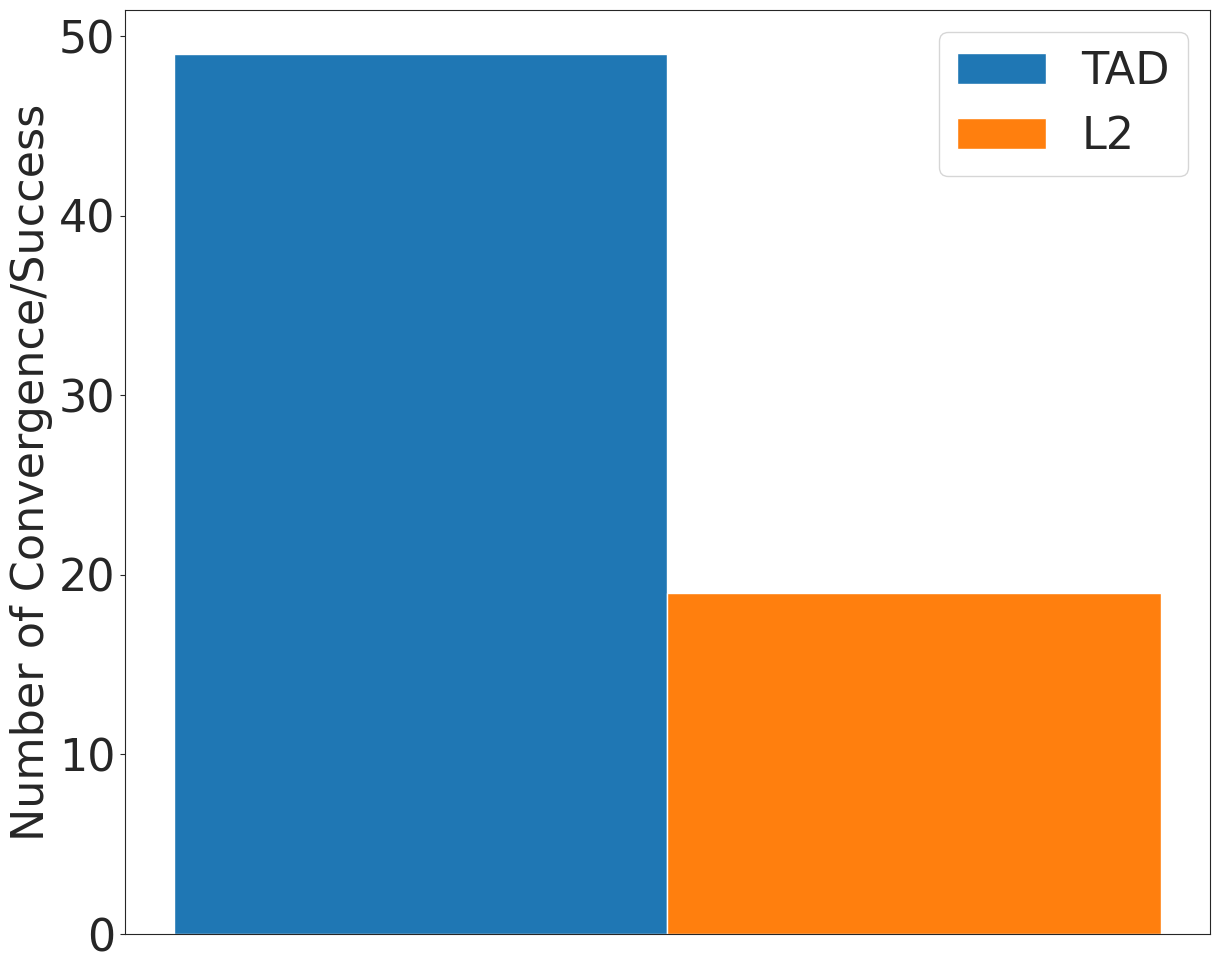

In [8]:
sns.set_style('ticks')
fig, ax = plt.subplots(figsize = (14,12))

methods = ["TAD"]
bar_width = 0.05
bar_positions = [i for i,_ in enumerate(methods)]

ax.bar("TAD", count_success_tad, bar_width, label = "TAD")
#ax.bar([p+bar_width for p in bar_positions], count_success_batchL2, bar_width, label = "Batch L2")
ax.bar([p+bar_width for p in bar_positions], count_success_L2, bar_width, label = "L2")

# ax.bar("lkj", iter_tad, bar_width)

#ax.set_xlabel('Methods')
ax.set_ylabel('Number of Convergence/Success')
ax.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False)
#plt.title("Uniform Distribution Histogram (Bin size 20)")
# ax.set_xlim(0, 1)
# ax.set_ylim(0, 20)
# plt.xticks(np.arange(0, 1.2, step=.2))
# plt.yticks(np.arange(0, 21, step=2.))
# #ax.set_axis([0, 1, 0, 20]) # x_start, x_end, y_start, y_end
#ax.grid(True)
ax.legend()
#plt.show()

plt.savefig('figures/NumberofConvSuccessTadvsL2vstart-22_random_noseed.jpg', dpi=300, bbox_inches='tight')
plt.show(block = False)

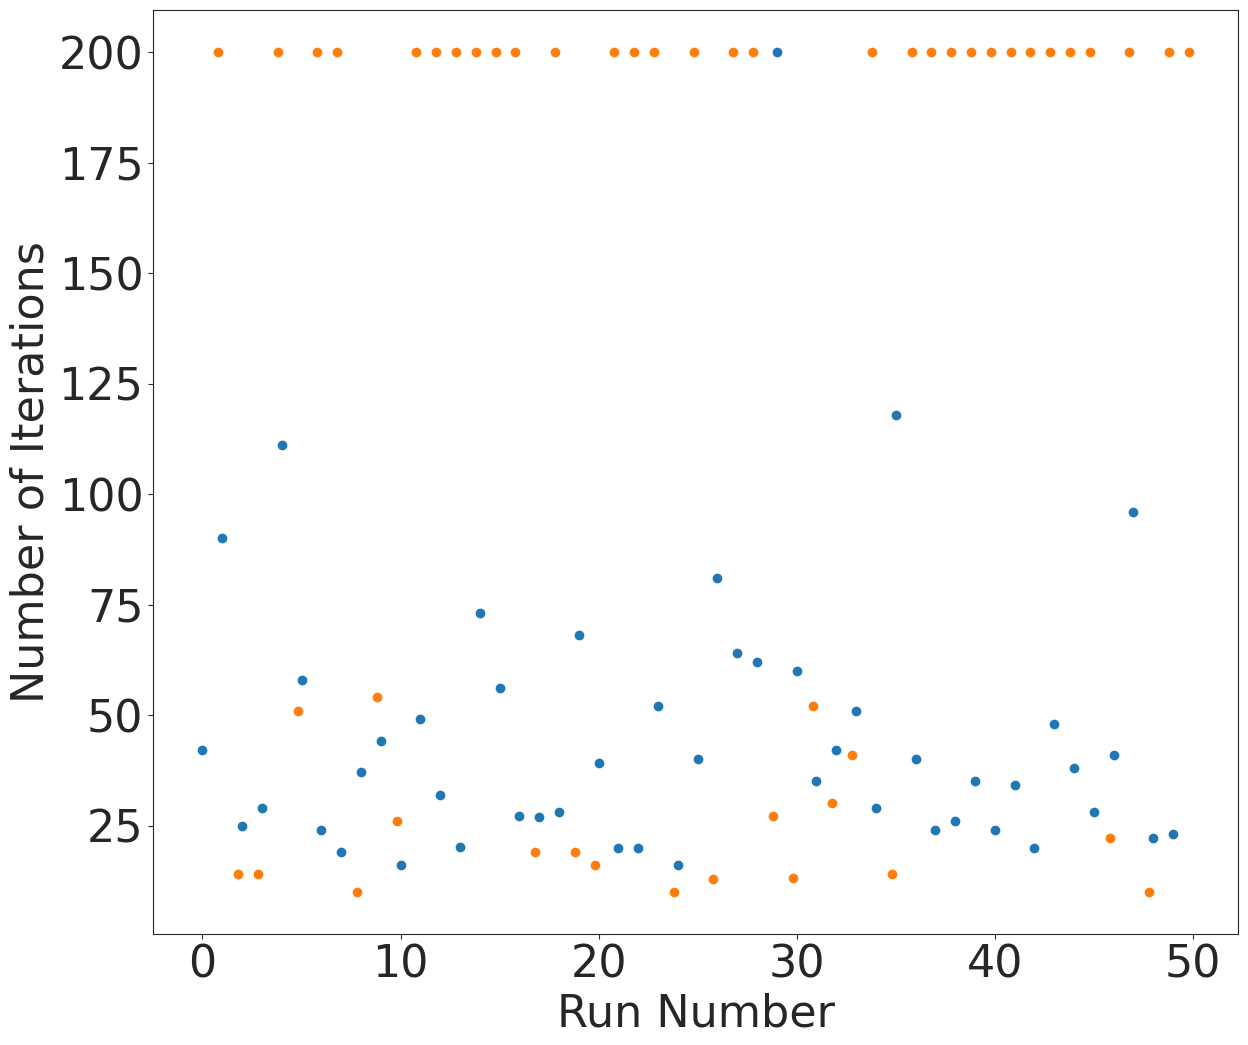

In [9]:
# Assuming you have filled method1_iterations and method2_iterations lists
fig, ax = plt.subplots(figsize = (14,12))
method1_iterations = iter_tad
method2_iterations = iter_L2
method3_iterations = iter_batchL2
# Create jitter for better scatter plot visualization
jitter_width = 0.1  # Adjust for desired spread
jittered_method1 = method1_iterations + np.random.rand(len(method1_iterations)) * jitter_width
jittered_method2 = method2_iterations + np.random.rand(len(method2_iterations)) * jitter_width
#jittered_method3 = method3_iterations + np.random.rand(len(method3_iterations)) * jitter_width

# Create the plot with box plots and scatter plots
#plt.boxplot([method1_iterations, method2_iterations], labels=["TAD", "Batch L2"], notch=True)
plt.scatter(np.arange(len(jittered_method1)) , jittered_method1, label="TAD", alpha=1.)
#plt.scatter(np.arange(len(jittered_method3))+ 0.4, jittered_method3, label="Batch L2", alpha=1.)
plt.scatter(np.arange(len(jittered_method2))+ 0.8, jittered_method2, label="L2", alpha=1.)

# Add labels and title
plt.xlabel("Run Number")
plt.ylabel("Number of Iterations")
#plt.title("Convergence Behavior Comparison (Box Plots & Scatter)")
#plt.legend()  # Add legend for scatter plots

# Display the plot
#plt.grid(axis='y')
plt.savefig('figures/IterTadvsL2start-22_random_noseed.pdf', dpi=300, bbox_inches='tight')
plt.show()

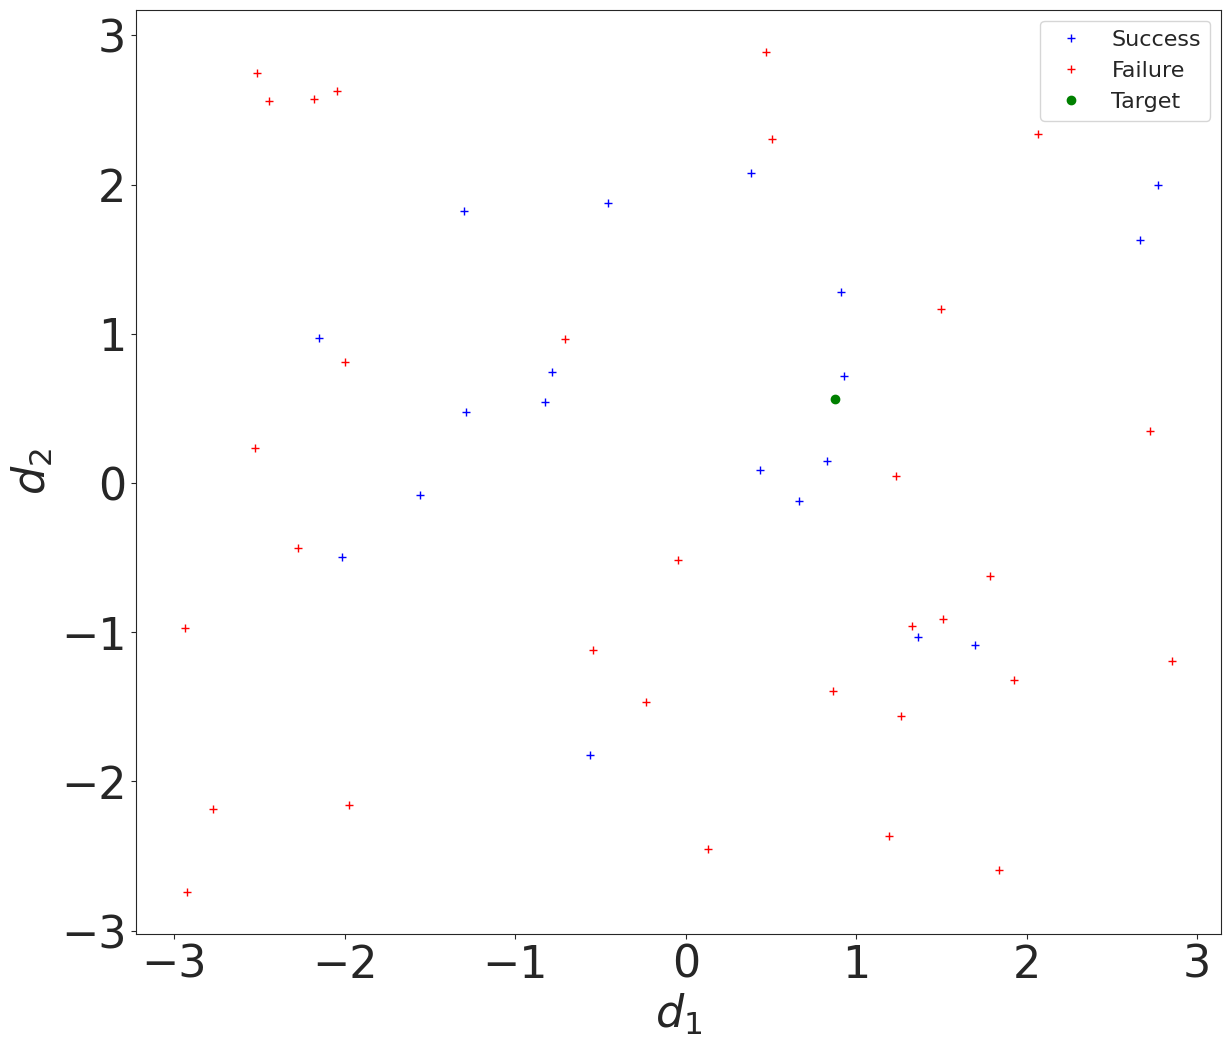

In [15]:
fig, ax = plt.subplots(figsize = (14,12))
plt.plot(vec_x_L2_success[:,0], vec_x_L2_success[:,1], 'b+', label = "Success")
plt.plot(vec_x_L2_fail[:,0], vec_x_L2_fail[:,1], 'r+', label = 'Failure')
plt.plot(0.8731, 0.5664, 'go', label = 'Target')
plt.xlabel("$d_1$")
plt.ylabel("$d_2$")
plt.rc('legend', fontsize=16) 
plt.legend()
plt.savefig('figures/InitializationL2.pdf', dpi=300, bbox_inches='tight')
plt.show()

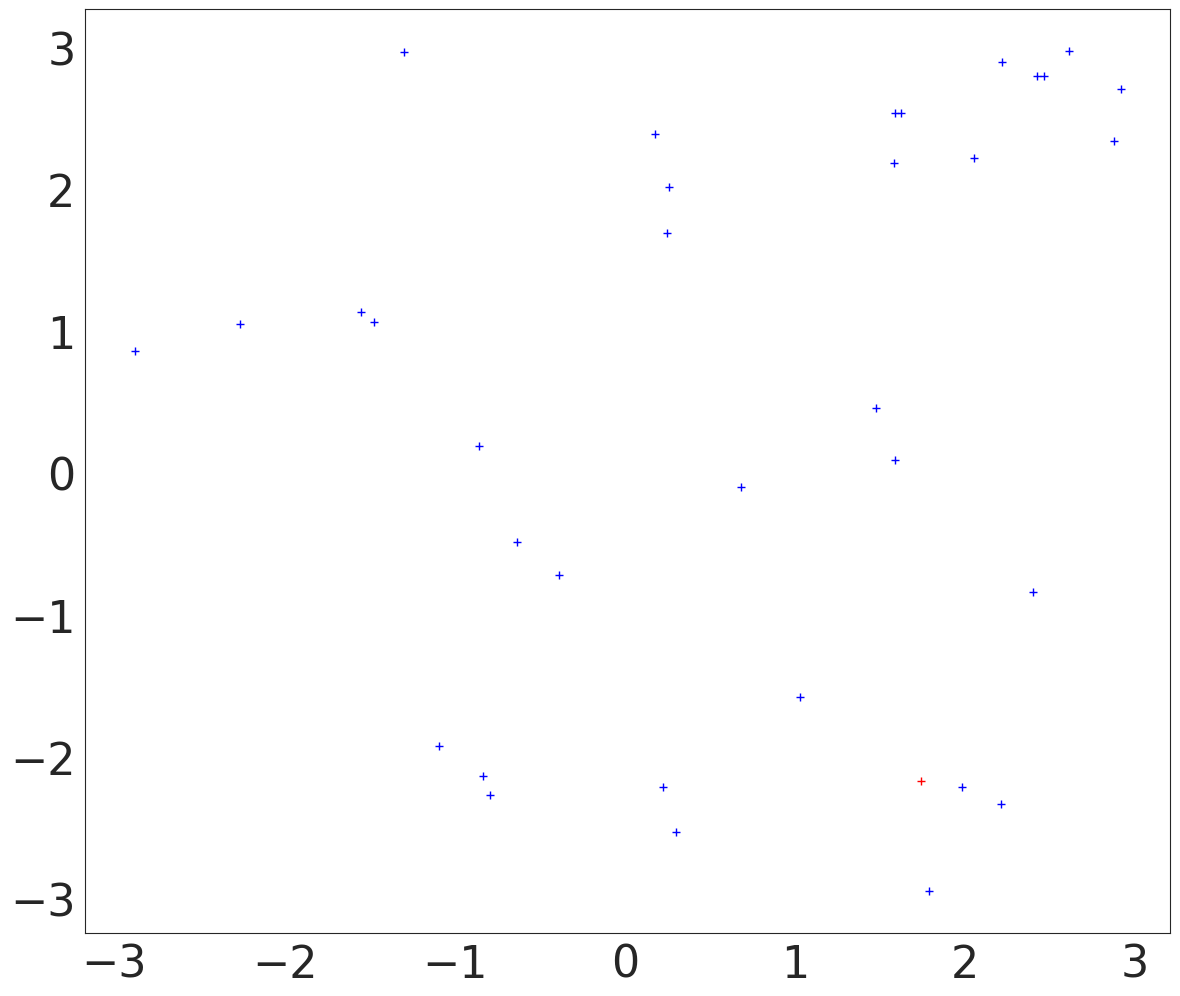

In [39]:
fig, ax = plt.subplots(figsize = (14,12))
plt.plot(vec_x_tad_success[:,0], vec_x_tad_success[:,1], 'b+')
plt.plot(vec_x_tad_fail[:,0], vec_x_tad_fail[:,1], 'r+')

In [87]:
vf = ObjFun()
f_target = vf.tgt_vec#.to(device)
sample_size = 4
D = vf.D
N = vf.N

vf.low = -3.
vf.high = 3.

high_minus_low = vf.high- vf.low
#high_minus_low = -
def g_theta(sample_size, D,high_minus_low):
    loc_x = (2. - 1.0 )  * np.random.random_sample((sample_size,1)) + 1.0
    
    loc_y = (2.  -1.0)  * np.random.random_sample((sample_size,1)) - 2.
    loc = np.concatenate((loc_x, loc_y), 1)
    #loc = high_minus_low  * np.random.random_sample((sample_size,2)) + vf.low#(np.random.uniform(low=vf.low, high=vf.high, size=(sample_size, D)))
    return Tensor(loc)
# train_x = g_theta(sample_size, D)
# #train_x = Tensor([[-1.5, 1.5], [-1.5, 1.3]])
# print(train_x)
noise_value = 0.0004 #noise_free = 0.
def vfield_(x):
    x = x.reshape(x.shape[0],D)
    out = torch.zeros(x.shape[0], N)
    
    out = vf(x[:,0], x[:,1]) + torch.randn(Tensor(vf(x[:,0], x[:,1])).size()) * math.sqrt(noise_value)
    return out#.to(device) #/torch.max(out)





In [88]:
x_plot = np.linspace(-3., 3., 100)
y_plot = np.linspace(-3., 3., 100)
xv_plot, yv_plot = np.meshgrid(x_plot, y_plot)
n = x_plot.shape[0]
x_concat_ = torch.zeros(n * n, 2)

# n_sample = x_concat_.shape[0]
num_tasks = 2
i = 0
k = 0
while i < n*n:
    x_concat_[i:i+n,0] = Tensor(xv_plot[:,k])
    x_concat_[i:i+n,1] = Tensor(y_plot)
    k = k+1
    i = i+n
    

tgt_plot = vfield_(x_concat_)
def dvfield_(x):
    x = x.reshape(x.shape[0],D)
    out = torch.zeros(x.shape[0], N)
    
    df = vf.get_gradient(x[:,0], x[:,1]) #+ torch.randn(Tensor(vf(x[:,0], x[:,1])).size()) * math.sqrt(noise_value)
    df1 = df[:,0:1]
    df2 = df[:, 2:3]
    dout_1 = 2 * (df1) * tgt_plot
    dout_2 = 2 * (df2) * tgt_plot
    return torch.cat((dout_1,dout_2),1)#.to(device) #/torch.max(out)
print(tgt_plot.shape)

torch.Size([10000, 2])


In [89]:
import matplotlib.ticker
class OOMFormatter(matplotlib.ticker.ScalarFormatter):
    def __init__(self, order=0, fformat="%1.1f", offset=True, mathText=True):
        self.oom = order
        self.fformat = fformat
        matplotlib.ticker.ScalarFormatter.__init__(self,useOffset=offset,useMathText=mathText)
    def _set_order_of_magnitude(self):
        self.orderOfMagnitude = self.oom
    def _set_format(self, vmin=None, vmax=None):
        self.format = self.fformat
        if self._useMathText:
             self.format = r'$\mathdefault{%s}$' % self.format

torch.Size([10000, 2])
torch.Size([100, 100])


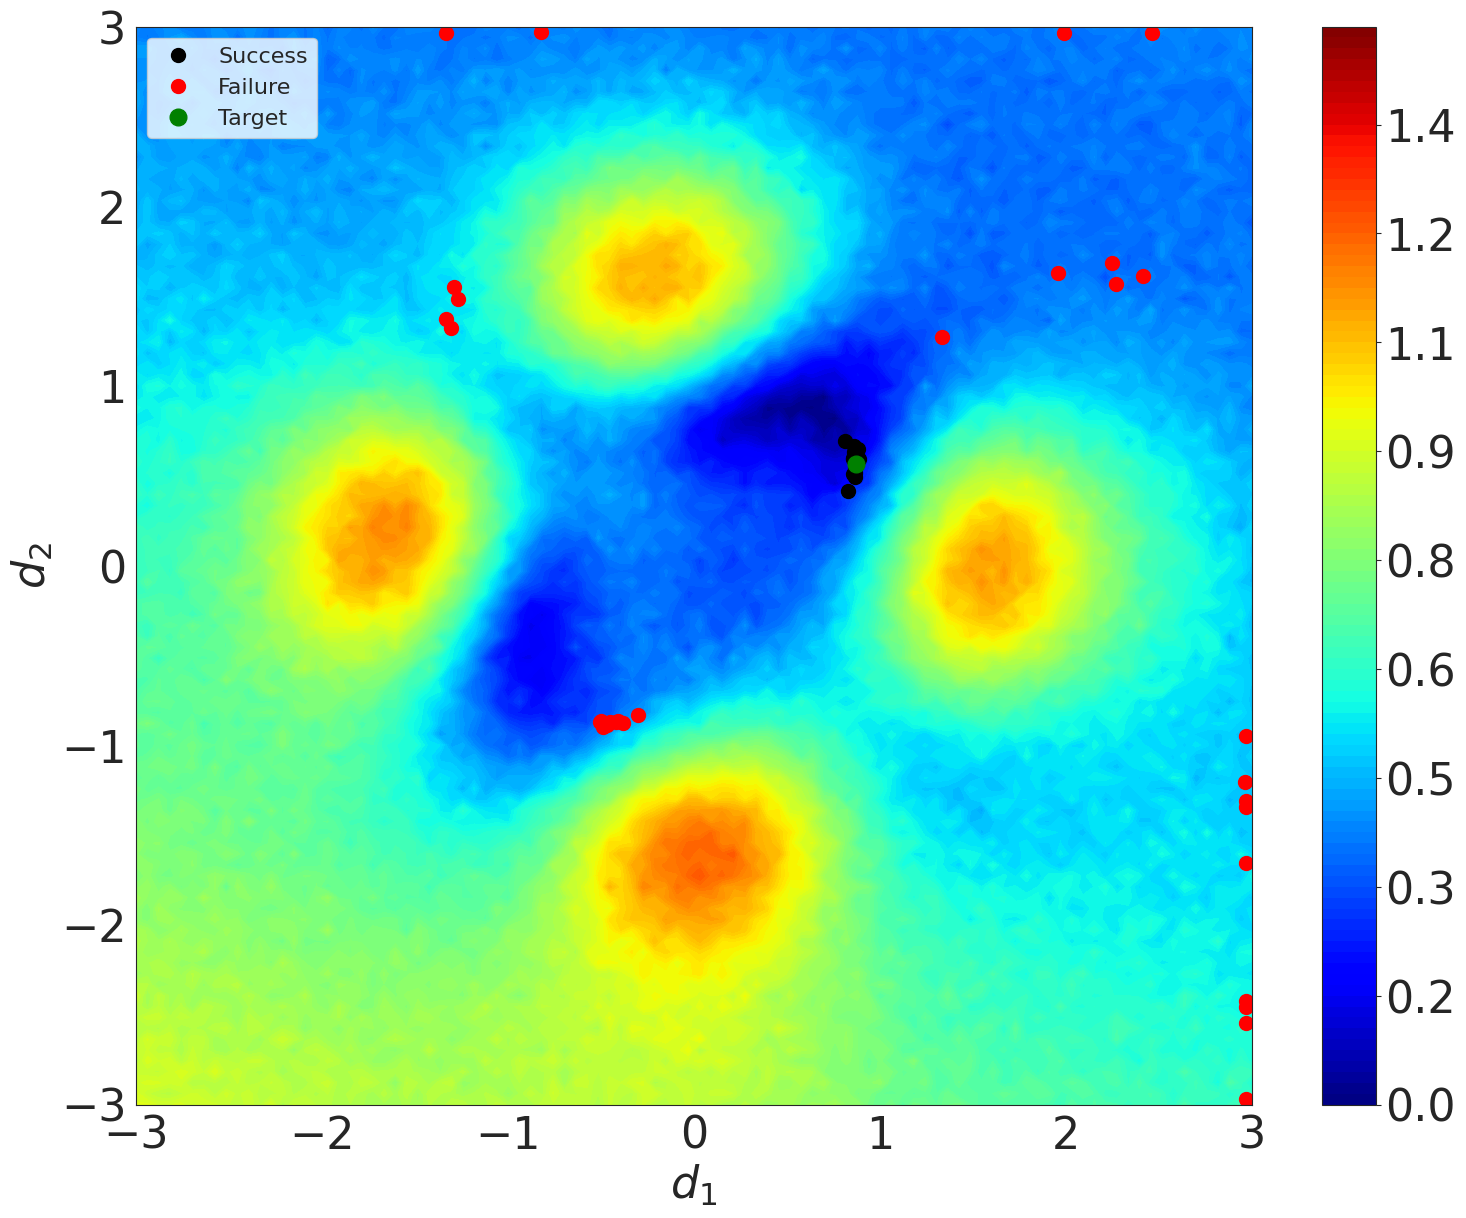

In [90]:
fig, ax = plt.subplots(figsize = (18,14))
print((tgt_plot - f_target).shape)
L2_norm = torch.linalg.norm(tgt_plot - f_target, dim = 1).reshape(n,n)
print(L2_norm.shape)#.reshape(n,n)
#np.linspace(0, 1.5, 100)
cs20 = ax.contourf(xv_plot, yv_plot, L2_norm, np.linspace(0, 1.5, 100), cmap = 'jet')
cbar20 = fig.colorbar(cs20, ax = ax,format=OOMFormatter(0, mathText=False));
plt.plot(vec_x_L2_success[:,0], vec_x_L2_success[:,1], 'ko', label = "Success", markersize = 10)
plt.plot(vec_x_L2_fail[:,0], vec_x_L2_fail[:,1], 'ro', label = 'Failure', markersize = 10)
plt.plot(0.8731, 0.5664, 'go', label = 'Target', markersize = 12)
plt.xlabel("$d_1$")
plt.ylabel("$d_2$")
plt.rc('legend', fontsize=16) 
plt.legend()
plt.savefig('figures/EndL2_cmap_nonoise.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [91]:
d_tgt_plot = dvfield_(x_concat_)

In [92]:
print(d_tgt_plot.shape)

torch.Size([10000, 4])


torch.Size([10000, 2])
torch.Size([100, 100])


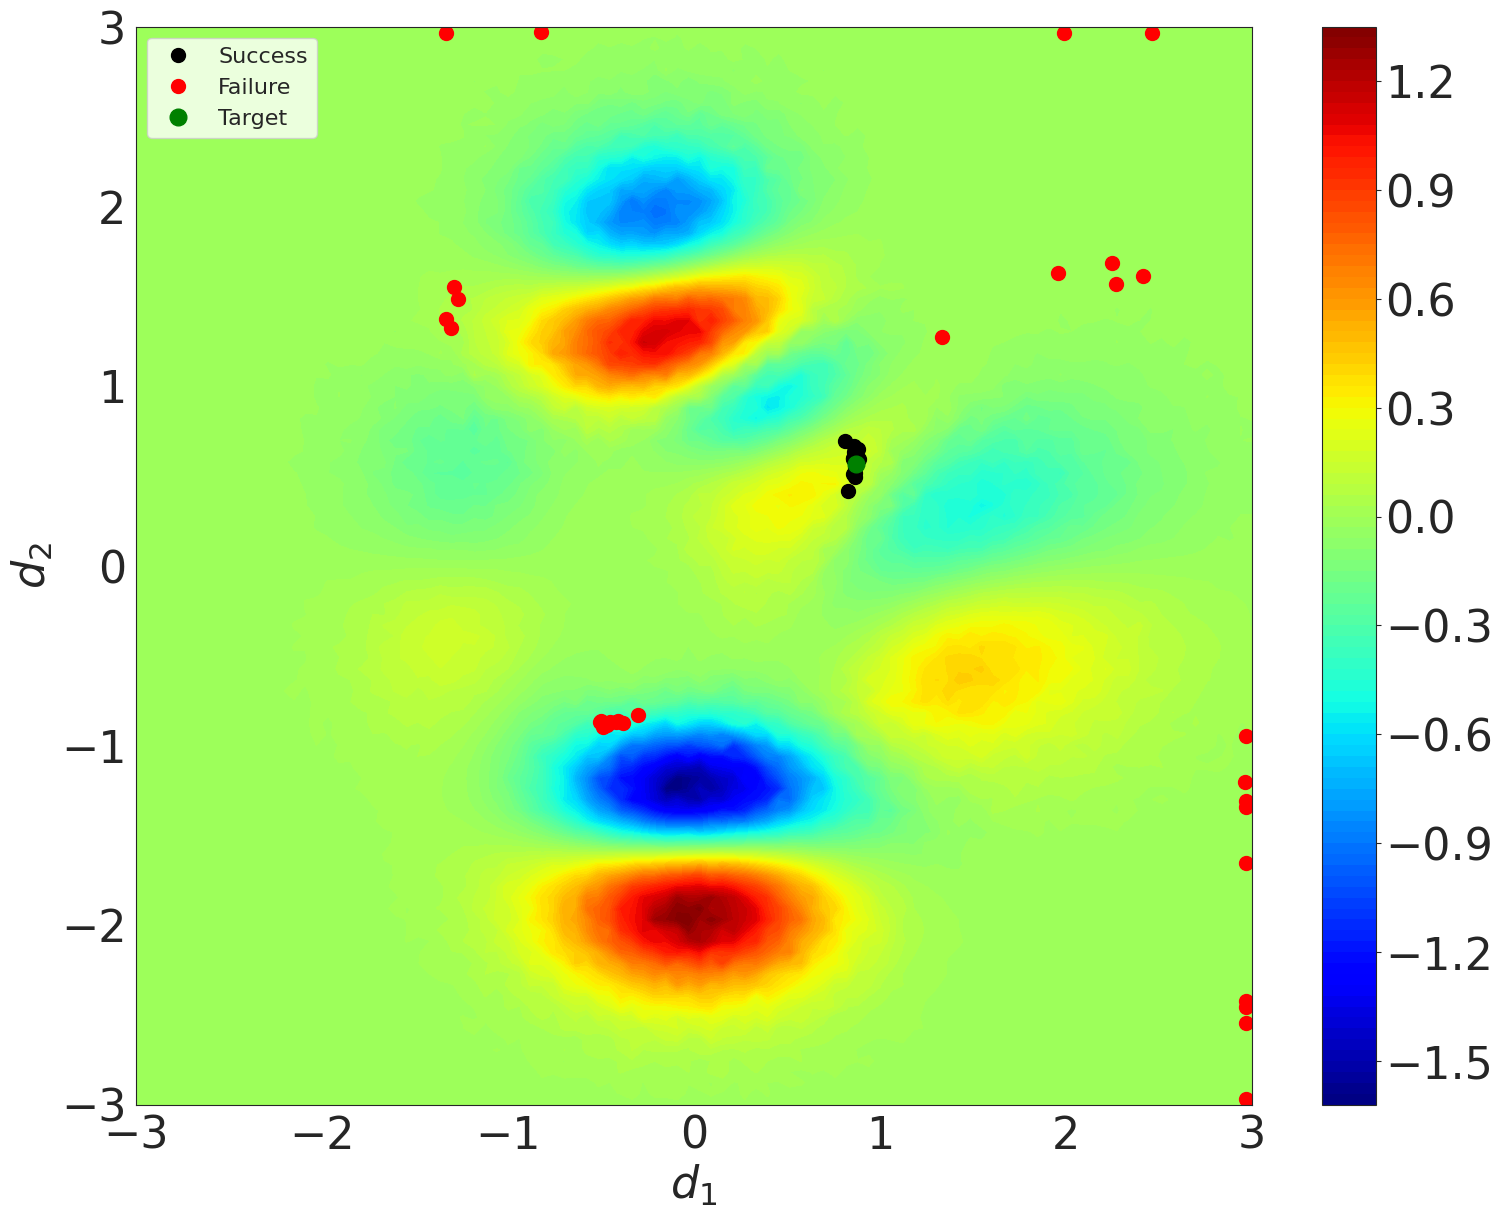

In [97]:
fig, ax = plt.subplots(figsize = (18,14))
print((tgt_plot - f_target).shape)
L2_norm = torch.linalg.norm(tgt_plot - f_target, dim = 1).reshape(n,n)
print(L2_norm.shape)#.reshape(n,n)
#np.linspace(0, 1.5, 100)
dplot = d_tgt_plot[:,3].reshape(n,n)
cs20 = ax.contourf(xv_plot, yv_plot,dplot , np.linspace(torch.min(dplot), torch.max(dplot), 100), cmap = 'jet')
cbar20 = fig.colorbar(cs20, ax = ax,format=OOMFormatter(0, mathText=False));
plt.plot(vec_x_L2_success[:,0], vec_x_L2_success[:,1], 'ko', label = "Success", markersize = 10)
plt.plot(vec_x_L2_fail[:,0], vec_x_L2_fail[:,1], 'ro', label = 'Failure', markersize = 10)
plt.plot(0.8731, 0.5664, 'go', label = 'Target', markersize = 12)
plt.xlabel("$d_1$")
plt.ylabel("$d_2$")
plt.rc('legend', fontsize=16) 
plt.legend()
plt.savefig('figures/derivEndL2_cmap_nonoise0.pdf', dpi=300, bbox_inches='tight')
plt.show()